In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("barber/tiempos.txt", sep="\s+")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\roxan\AppData\Local\Temp\ipykernel_5916\2392173068.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("barber/tiempos.txt", sep="\s+")


In [7]:
df

,procs,rep,real,user,sys
0,2,1,21.920896,15.016458,6.884572
1,2,2,20.999153,14.700502,6.281282
2,2,3,20.953137,14.714899,6.216528
3,2,4,22.329906,15.708869,6.610109
4,2,5,20.866437,14.503591,6.340612
...,...,...,...,...,...
65,8,6,1.767400,1.119822,0.638540
66,8,7,1.517672,0.818263,0.694506
67,8,8,1.047243,0.698997,0.345474
68,8,9,1.599134,0.849203,0.744631


In [8]:
stats = df.groupby("procs")[["real", "user", "sys"]].agg(["mean", "std"])

In [13]:
procs = stats.index

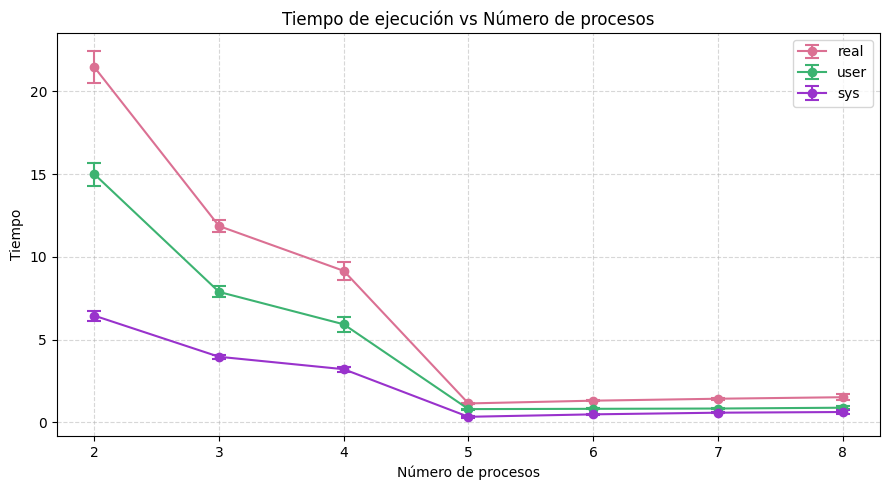

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))


for col, color, label in [("real", "palevioletred", "real"), 
                           ("user", "mediumseagreen", "user"), 
                           ("sys",  "darkorchid", "sys")]:
    mean = stats[col]["mean"]
    std  = stats[col]["std"]
    ax.errorbar(procs, mean, yerr=std, marker="o", color=color, 
                label=label, capsize=5, capthick=1.5, elinewidth=1.5)

ax.set_xlabel("Número de procesos")
ax.set_ylabel("Tiempo")
ax.set_title("Tiempo de ejecución vs Número de procesos")
ax.set_xticks(procs)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("tiempos.png", dpi=150)
plt.show()